In [66]:
import numpy as np
import os
import matplotlib.pyplot as plt
import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import xml.etree.ElementTree as ET
from constants import ImzMLFileParser
import anndata as ad
import mudata as mu
import pandas as pd
import matplotlib.patches as mpatches

In [2]:
def read_ibm_file(path: str, sample_id: str, modality_name: str) -> tuple[np.ndarray, np.ndarray]:

    sample_path = os.path.join(path, sample_id)
    mod_path = os.path.join(sample_path, modality_name)

    # Check if the path exists
    if not os.path.exists(mod_path):
        raise FileNotFoundError(f"Path {mod_path} does not exist.")

    # List the files in the given directory and extract the absolute path for the first imzML file
    files = os.listdir(mod_path)
    imzml_files = [f for f in files if f.endswith('.imzML')]
    if len(imzml_files) == 0:
        raise FileNotFoundError(f"No imzML files found in {mod_path}.")
    imzml_file = os.path.join(mod_path, imzml_files[0])

    # Obtain the IBD file using the same filename and swapping the extension
    ibd_file = imzml_file.replace('.imzML', '.ibd')
    if not os.path.exists(ibd_file):
        raise FileNotFoundError(f"IBD file {ibd_file} not found in {mod_path}.")

    print(f"Reading imzML file: {imzml_file}, associated with IBD file {ibd_file}")

    # Parse the imzML file
    tree = ET.parse(imzml_file)
    root = tree.getroot()

    mz_dtype, intensities_dtype = None, None

    # Define utility to convert string to dtype
    str_to_dtype = lambda s: np.float32 if s == "32-bit float" else np.float64

    for rpg in root.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_LIST):
        if rpg.attrib['id'] in ['mzArray']:
            for cv_param in rpg:
                if "float" in cv_param.attrib['name']:
                    mz_dtype = str_to_dtype(cv_param.attrib['name'])
        elif rpg.attrib['id'] in ['intensities', "intensityArray"]:
            for cv_param in rpg:
                if "float" in cv_param.attrib['name']:
                    intensities_dtype = str_to_dtype(cv_param.attrib['name'])

    if mz_dtype is None:
        mz_dtype = np.float64 if intensities_dtype == None else intensities_dtype
    if intensities_dtype is None:
        intensities_dtype = mz_dtype

    run = root.find(ImzMLFileParser.RUN_KEY)
    spectrum_list = run.find(ImzMLFileParser.SPECTRUM_LIST_KEY)
    spectra = spectrum_list.findall(ImzMLFileParser.SPECTRUM_KEY)

    # Decode the binary data from the imzML file
    parsed_spectra = [lipidomics.spectra_to_dict(spectrum) for spectrum in spectra]

    # Select the final data type based on the largest one
    final_dtype = np.promote_types(mz_dtype, intensities_dtype)

    # Read the binary IBD data file to obtain the actual M/Zs and intensities data
    read_mzs = lambda metadata: np.fromfile(ibd_file, dtype = mz_dtype, count = metadata['length'], offset = metadata['offset'])
    read_intensities = lambda metadata: np.fromfile(ibd_file, dtype = intensities_dtype, count = metadata['length'], offset = metadata['offset'])

    # Read the data from the IBD file
    mzs = [read_mzs(metadata["mzs"]) for metadata in parsed_spectra]
    intensities = [read_intensities(metadata["intensities"]) for metadata in parsed_spectra]

    # Obtain the lower and upper bounds for the mzs values
    low_mz, high_mz = float('inf'), float('-inf')
    for mz in mzs:
        if np.min(mz) < low_mz:
            low_mz = np.min(mz)
        if np.max(mz) > high_mz:
            high_mz = np.max(mz)

    return mzs, intensities

In [3]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Nacho"
SAMPLE_ID_LIST = [
    "PWB929C",
    "PWB931C",
    "PWB934C",
    "PWB941C",
    "PWB943C",
    "PWB947C",
    "PWB950C",
    "PWB952C",
    "PWB929N",
    "PWB931N",
    "PWB934N",
    "PWB941N",
    "PWB943N",
    "PWB947N",
    "PWB950N",
    "PWB952N"
]
MODALITY_NAME = "msi"

OUTPUT_PATH_LIST = [os.path.join(PATH, sample_id, 'preprocessing', MODALITY_NAME) for sample_id in SAMPLE_ID_LIST]

In [4]:
global_mzs, global_intensities = [], []

for sample_id in SAMPLE_ID_LIST:
    mzs, intensities = read_ibm_file(PATH, sample_id, MODALITY_NAME)
    global_mzs.append(mzs)
    global_intensities.append(intensities)

Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB941C/msi/PWB941_cancer_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB941C/msi/PWB941_cancer_10um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB943C/msi/PWB943_cancer_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB943C/msi/PWB943_cancer_20um_rec

In [5]:
# Define an omogenous M/Z array that aggregates datapoints to achieve a common spectrum
reference_mz = []
for sample_index in range(len(SAMPLE_ID_LIST)):
    reference_mz.append(lipidomics.compute_reference_mz(global_mzs[sample_index], mass_tollerance=10, frequency_threshold=0.01))
    print(f"Found {len(reference_mz[-1])} unique M/Z values from sample {SAMPLE_ID_LIST[sample_index]}: [{min(reference_mz[-1])}, {max(reference_mz[-1])}]")

Total unique m/z values: 2176059. The process will iterate as long as there are overlapping clusters.



Computing consensus m/z: 100%|██████████| 10/10 [00:00<00:00, 15.74batch/s]


Found 4667 unique M/Z values from sample PWB929C: [350.0408630371094, 1993.035400390625]
Total unique m/z values: 2834373. The process will iterate as long as there are overlapping clusters.



Computing consensus m/z: 100%|██████████| 10/10 [00:00<00:00, 16.84batch/s]


Found 6171 unique M/Z values from sample PWB931C: [350.04779052734375, 1994.0186767578125]
Total unique m/z values: 2021008. The process will iterate as long as there are overlapping clusters.



...

Found 6356 unique M/Z values from sample PWB947N: [350.047119140625, 1994.051513671875]
Total unique m/z values: 2593479. The process will iterate as long as there are overlapping clusters.



Computing consensus m/z: 100%|██████████| 10/10 [00:00<00:00, 19.04batch/s]


Found 5214 unique M/Z values from sample PWB950N: [350.0472106933594, 1994.03857421875]
Total unique m/z values: 2947321. The process will iterate as long as there are overlapping clusters.



Computing consensus m/z: 100%|██████████| 10/10 [00:00<00:00, 16.66batch/s]

Found 6041 unique M/Z values from sample PWB952N: [350.0469055175781, 1996.0185546875]


In [7]:
# Now process again the unified M/Z to reach a global consensus across all samples
global_reference_mz = lipidomics.compute_reference_mz(reference_mz, mass_tollerance=10, frequency_threshold=0.0)    # No frequency threshold because the frequncies will be more or less homogeneous
print(f"Found {len(global_reference_mz)} global unique M/Z values: [{min(global_reference_mz)}, {max(global_reference_mz)}]")

Total unique m/z values: 81697. The process will iterate as long as there are overlapping clusters.



Computing consensus m/z: 100%|██████████| 3/3 [00:00<00:00, 36.27batch/s]

Found 6401 global unique M/Z values: [350.078125, 1995.0172119140625]


In [8]:
# Use the unified M/Z values to preprocess each sample
for sample_id in SAMPLE_ID_LIST:
    lipidomics.preprocess_lipidomics(
        path = PATH,
        sample_id= sample_id,
        modality_name = MODALITY_NAME,
        peak_picking= True,
        prominence=0.01,
        window_tolerance=10,
        dynamic_window=True,
        dynamic_window_factor = 1e6,
        reference_mz = global_reference_mz,
    )

Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.ibd


Interpolating intensities: 100%|██████████| 39158/39158 [02:32<00:00, 256.48it/s]


Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.ibd


Interpolating intensities: 100%|██████████| 35833/35833 [03:20<00:00, 179.02it/s]


Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.ibd


...

Interpolating intensities: 100%|██████████| 44215/44215 [03:40<00:00, 200.25it/s]


Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB950N/msi/PWB950_normal_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB950N/msi/PWB950_normal_20um_recal_M2.ibd


Interpolating intensities: 100%|██████████| 39652/39652 [03:47<00:00, 174.64it/s]


Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB952N/msi/PWB952_normal_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB952N/msi/PWB952_normal_10um_recal_M2.ibd


Interpolating intensities: 100%|██████████| 46291/46291 [04:02<00:00, 191.21it/s]


In [10]:
# Create a new AnnData object to store the processed data
adata = ad.AnnData()

In [48]:
# Initialize empty AnnData object
adata = None

for sample_id in SAMPLE_ID_LIST:
    sample_path = os.path.join(PATH, sample_id, 'preprocessing', MODALITY_NAME)
    intensities_matrix = np.load(os.path.join(sample_path, f'{sample_id}_intensities_matrix.npy'))

    # Create coordinate matrix with correct dimensions
    coordinates = np.zeros((intensities_matrix.shape[0], intensities_matrix.shape[1], 2), dtype=np.int16)
    for i in range(intensities_matrix.shape[0]):
        coordinates[i, :, 0] = i  # X coordinate
        coordinates[i, :, 1] = np.arange(intensities_matrix.shape[1])  # Y coordinate
    
    # Flatten arrays while preserving feature dimension
    coordinates = coordinates.reshape(-1, 2)
    intensities = intensities_matrix.reshape(-1, intensities_matrix.shape[2])

    # Create sample AnnData with categorical batch_id
    sample_adata = ad.AnnData(
        X=intensities,
        obs=pd.DataFrame({
            'batch_id': pd.Categorical([sample_id] * intensities.shape[0])
        }, index=[f"{sample_id}_cell_{i}" for i in range(intensities.shape[0])]),
        var=pd.DataFrame({'mz': global_reference_mz}, index=[str(mz) for mz in global_reference_mz]),
        obsm={'coordinates': coordinates}
    )

    # Concatenate samples
    if adata is None:
        adata = sample_adata
    else:
        adata = ad.concat(
            [adata, sample_adata],

        )

# Save the AnnData object to a file
adata_path = os.path.join(PATH, 'global_merge', 'lipidomics_data.h5ad')

In [52]:
# Save the AnnData object
adata.write(adata_path)
print(f"AnnData object saved to {adata_path}")

AnnData object saved to /mnt/data/lorenzo/VSC_DATA/Nacho/global_merge/lipidomics_data.h5ad


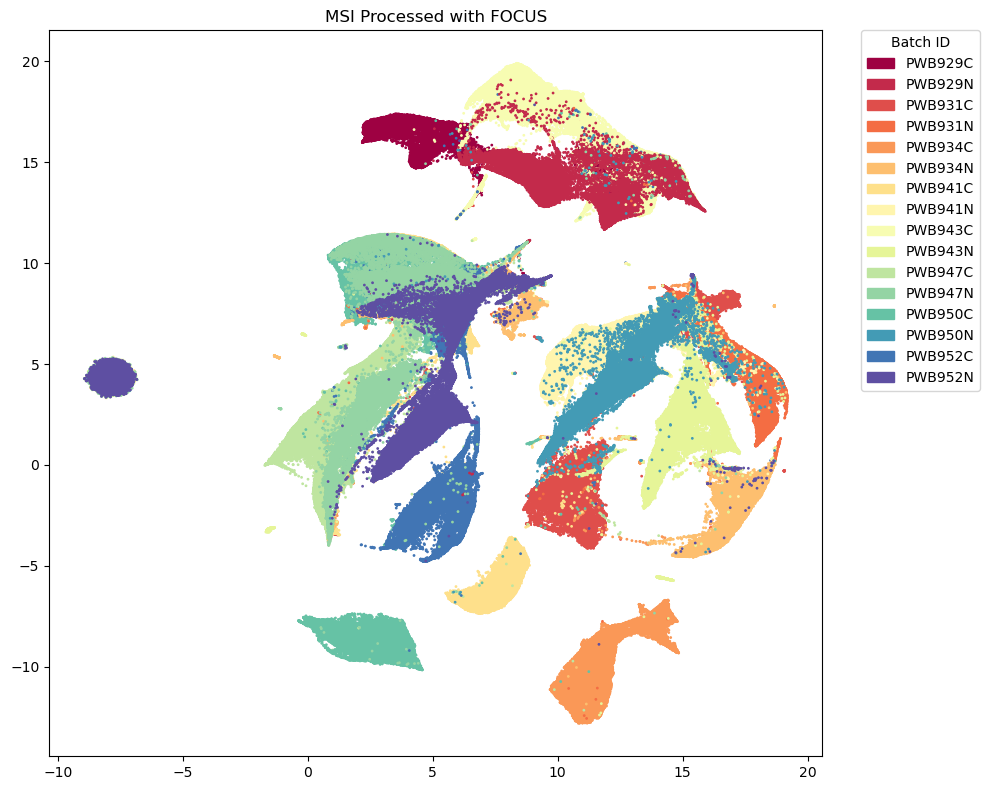

In [70]:
from sklearn.decomposition import PCA
import umap

# Get the colormap and normalization
cmap = plt.get_cmap('Spectral')
norm = plt.Normalize(vmin=adata.obs["batch_id"].astype('category').cat.codes.min(), vmax=adata.obs["batch_id"].astype('category').cat.codes.max())

# Create legend handles
handles = [
    mpatches.Patch(
        color=cmap(norm(code)),
        label=category
    )
    for code, category in enumerate(adata.obs["batch_id"].astype('category').cat.categories)
]

# Create UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(adata.X)

# Plot the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=adata.obs['batch_id'].astype('category').cat.codes, cmap='Spectral', s=1)
plt.title('MSI Processed with FOCUS')
plt.legend(
    handles=handles,          # your legend handles
    title='Batch ID',           # your legend title
    bbox_to_anchor=(1.05, 1), # position: just outside right
    loc='upper left',         # anchor legend's upper left corner
    borderaxespad=0.
)
plt.tight_layout()            # optional: reduces overlap
plt.show()

In [54]:
# Read MuData file
otf_prostate = mu.read("/mnt/data/lorenzo/VSC_DATA/prostate_multimodal.h5mu")

/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


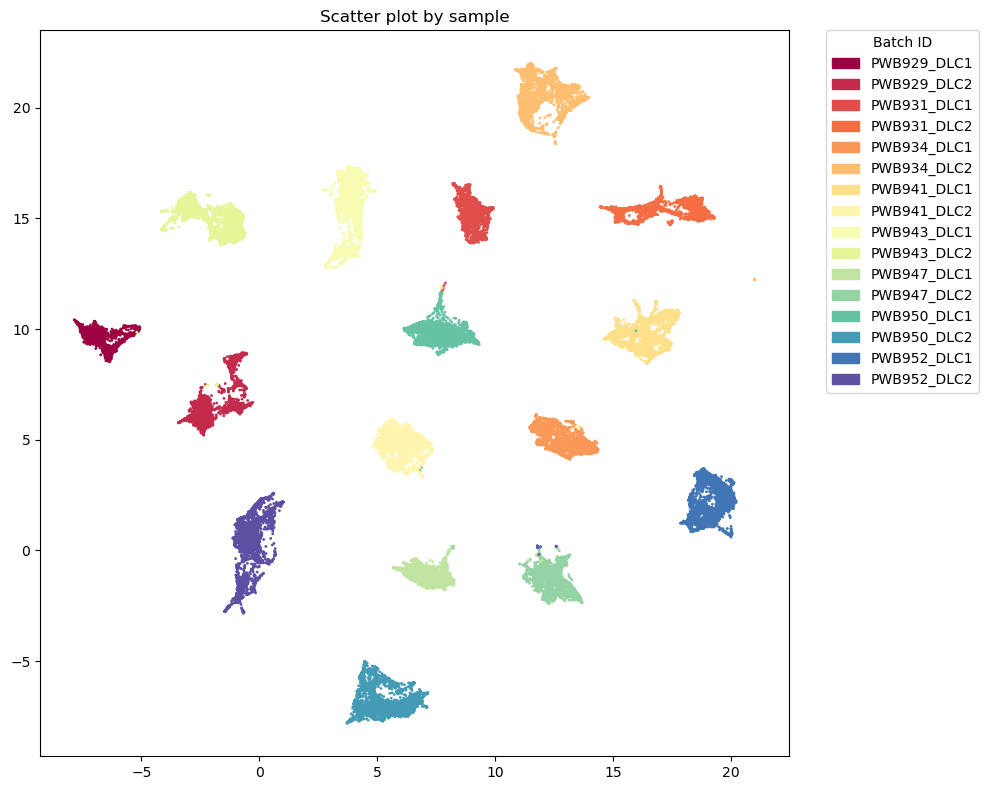

In [69]:
# Get the colormap and normalization
cmap = plt.get_cmap('Spectral')
norm = plt.Normalize(vmin=otf_prostate.mod['msi'].obs["sample"].astype('category').cat.codes.min(), vmax=otf_prostate.mod['msi'].obs["sample"].astype('category').cat.codes.max())

# Create legend handles
handles = [
    mpatches.Patch(
        color=cmap(norm(code)),
        label=category
    )
    for code, category in enumerate(otf_prostate.mod['msi'].obs["sample"].astype('category').cat.categories)
]

# Create UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(otf_prostate.mod['msi'].X)

# Plot the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=otf_prostate.mod['msi'].obs["sample"].astype('category').cat.codes, cmap='Spectral', s=1)
plt.title('MSI Processed with Aspects Analytica')


plt.title("Scatter plot by sample")
plt.legend(
    handles=handles,          # your legend handles
    title='Batch ID',           # your legend title
    bbox_to_anchor=(1.05, 1), # position: just outside right
    loc='upper left',         # anchor legend's upper left corner
    borderaxespad=0.
)
plt.tight_layout()            # optional: reduces overlap
plt.show()

In [82]:
from sklearn.decomposition import PCA
import umap

# Create UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(adata.X)

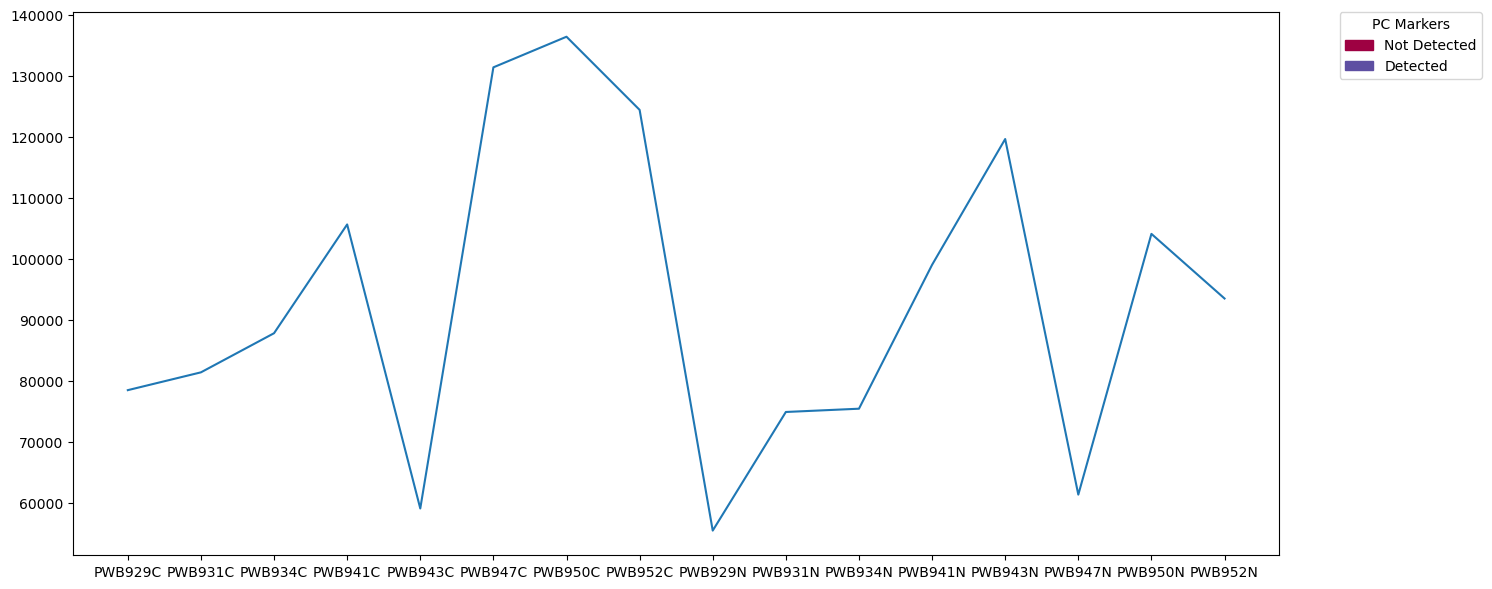

In [ ]:
# Filter the data based on the lipid thresholds
lipids = [716.5225, 728.56, 712.6, 714.6, 734.5, 736.6]
reference_mz_indexes = [np.argmin(np.abs(global_reference_mz - lipid)) for lipid in lipids]
thresholds = [max(adata.X[:, index]) * 0.01 for index in reference_mz_indexes]
total_count = {}

for batch_id in adata.obs['batch_id'].unique():
    data = adata[adata.obs['batch_id'] == batch_id]
    for index, threshold in zip(reference_mz_indexes, thresholds):
        positive_mask = data.X[:, index] > threshold
        count = np.sum(positive_mask)
        total_count[batch_id] = total_count[batch_id] + count if batch_id in total_count else count
    
plt.plot(total_count.keys(), total_count.values())


# Plot the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=mask, cmap='Spectral', s=1)
plt.title('MSI Processed with FOCUS with PC Markers filter')

# Get the colormap and normalization
cmap = plt.get_cmap('Spectral')
norm = plt.Normalize(vmin=False, vmax=True)

# Create legend handles
handles = [
    mpatches.Patch(
        color=cmap(norm(code)),
        label=category
    )
    for code, category in enumerate(['Not Detected', 'Detected'])
]
plt.legend(
    handles=handles,          # your legend handles
    title='PC Markers',           # your legend title
    bbox_to_anchor=(1.05, 1), # position: just outside right
    loc='upper left',         # anchor legend's upper left corner
    borderaxespad=0.
)
plt.tight_layout()            # optional: reduces overlap
plt.show()